# Data Understanding

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import skew

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, roc_auc_score, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

pd.set_option('display.max_columns', None)
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('✅ Library berhasil di-import')

✅ Library berhasil di-import


## Data Collection

In [3]:
df = pd.read_csv('dataset/data.csv', sep=';')
df.head(100)

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1,15,1,9119,1,1,130.0,26,38,3,9,2,137.0,1,0,0,1,1,0,19,1,0,5,9,5,14.000000,0,0,5,11,3,13.250000,0,13.9,-0.3,0.79,Enrolled
96,1,1,5,9773,1,1,135.0,1,37,1,5,5,124.9,1,0,0,1,0,0,18,0,0,6,6,6,13.666667,0,0,6,6,6,13.333333,0,8.9,1.4,3.51,Graduate
97,1,1,5,9500,1,1,132.0,1,37,37,7,7,120.3,1,0,0,1,0,1,18,0,0,7,7,7,13.750000,0,0,8,9,8,14.477778,0,12.4,0.5,1.79,Graduate
98,1,1,1,9085,1,1,135.0,1,1,2,9,1,134.3,1,0,0,1,0,0,19,0,0,5,7,5,14.200000,2,0,5,7,5,13.800000,0,12.7,3.7,-1.70,Enrolled


In [4]:
print('='*55)
print(f' Jumlah baris    : {df.shape[0]}')
print(f' Jumlah kolom    : {df.shape[1]}')
print('='*55)
df.info()

 Jumlah baris    : 4424
 Jumlah kolom    : 37
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualifica

In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Marital_status,4424.0,NaN,NaN,NaN,1.178571,0.605747,1.0,1.0,1.0,1.0,6.0
Application_mode,4424.0,NaN,NaN,NaN,18.669078,17.484682,1.0,1.0,17.0,39.0,57.0
Application_order,4424.0,NaN,NaN,NaN,1.727848,1.313793,0.0,1.0,1.0,2.0,9.0
Course,4424.0,NaN,NaN,NaN,8856.642631,2063.566416,33.0,9085.0,9238.0,9556.0,9991.0
Daytime_evening_attendance,4424.0,NaN,NaN,NaN,0.890823,0.311897,0.0,1.0,1.0,1.0,1.0
Previous_qualification,4424.0,NaN,NaN,NaN,4.577758,10.216592,1.0,1.0,1.0,1.0,43.0
Previous_qualification_grade,4424.0,NaN,NaN,NaN,132.613314,13.188332,95.0,125.0,133.1,140.0,190.0
Nacionality,4424.0,NaN,NaN,NaN,1.873192,6.914514,1.0,1.0,1.0,1.0,109.0
Mothers_qualification,4424.0,NaN,NaN,NaN,19.561935,15.603186,1.0,2.0,19.0,37.0,44.0
Fathers_qualification,4424.0,NaN,NaN,NaN,22.275316,15.343108,1.0,3.0,19.0,37.0,44.0


In [6]:
print('── Missing Values ──────────────────────────────')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Persen (%)': missing_pct})
print(missing_df[missing_df['Missing'] > 0] if missing.sum() > 0 else '✅ Tidak ada missing value')

print(f'\n── Duplikat ────────────────────────────────────')
print(f'Jumlah baris duplikat: {df.duplicated().sum()}')

── Missing Values ──────────────────────────────
✅ Tidak ada missing value

── Duplikat ────────────────────────────────────
Jumlah baris duplikat: 0


## Exploratory Data Analysis

### Target Distribution

Distribusi Status:
Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Persentase:
Status
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: count, dtype: float64


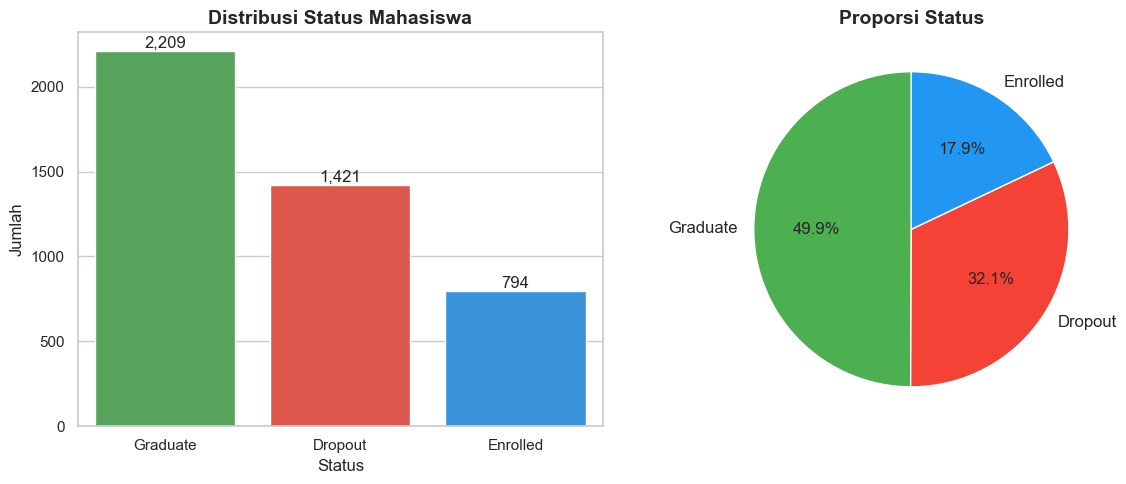

In [7]:
status_counts = df['Status'].value_counts()
print('Distribusi Status:')
print(status_counts)
print('\nPersentase:')
print((status_counts / len(df) * 100).round(2))

colors = ['#4CAF50', '#F44336', '#2196F3']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='Status', data=df, order=status_counts.index,
              palette=colors, ax=axes[0])
axes[0].set_title('Distribusi Status Mahasiswa', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Jumlah')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=12)

axes[1].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Proporsi Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Numeric Feature Distribution

Kolom kontinu: ['Previous_qualification_grade', 'Admission_grade', 'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_grade', 'Unemployment_rate', 'Inflation_rate', 'GDP']


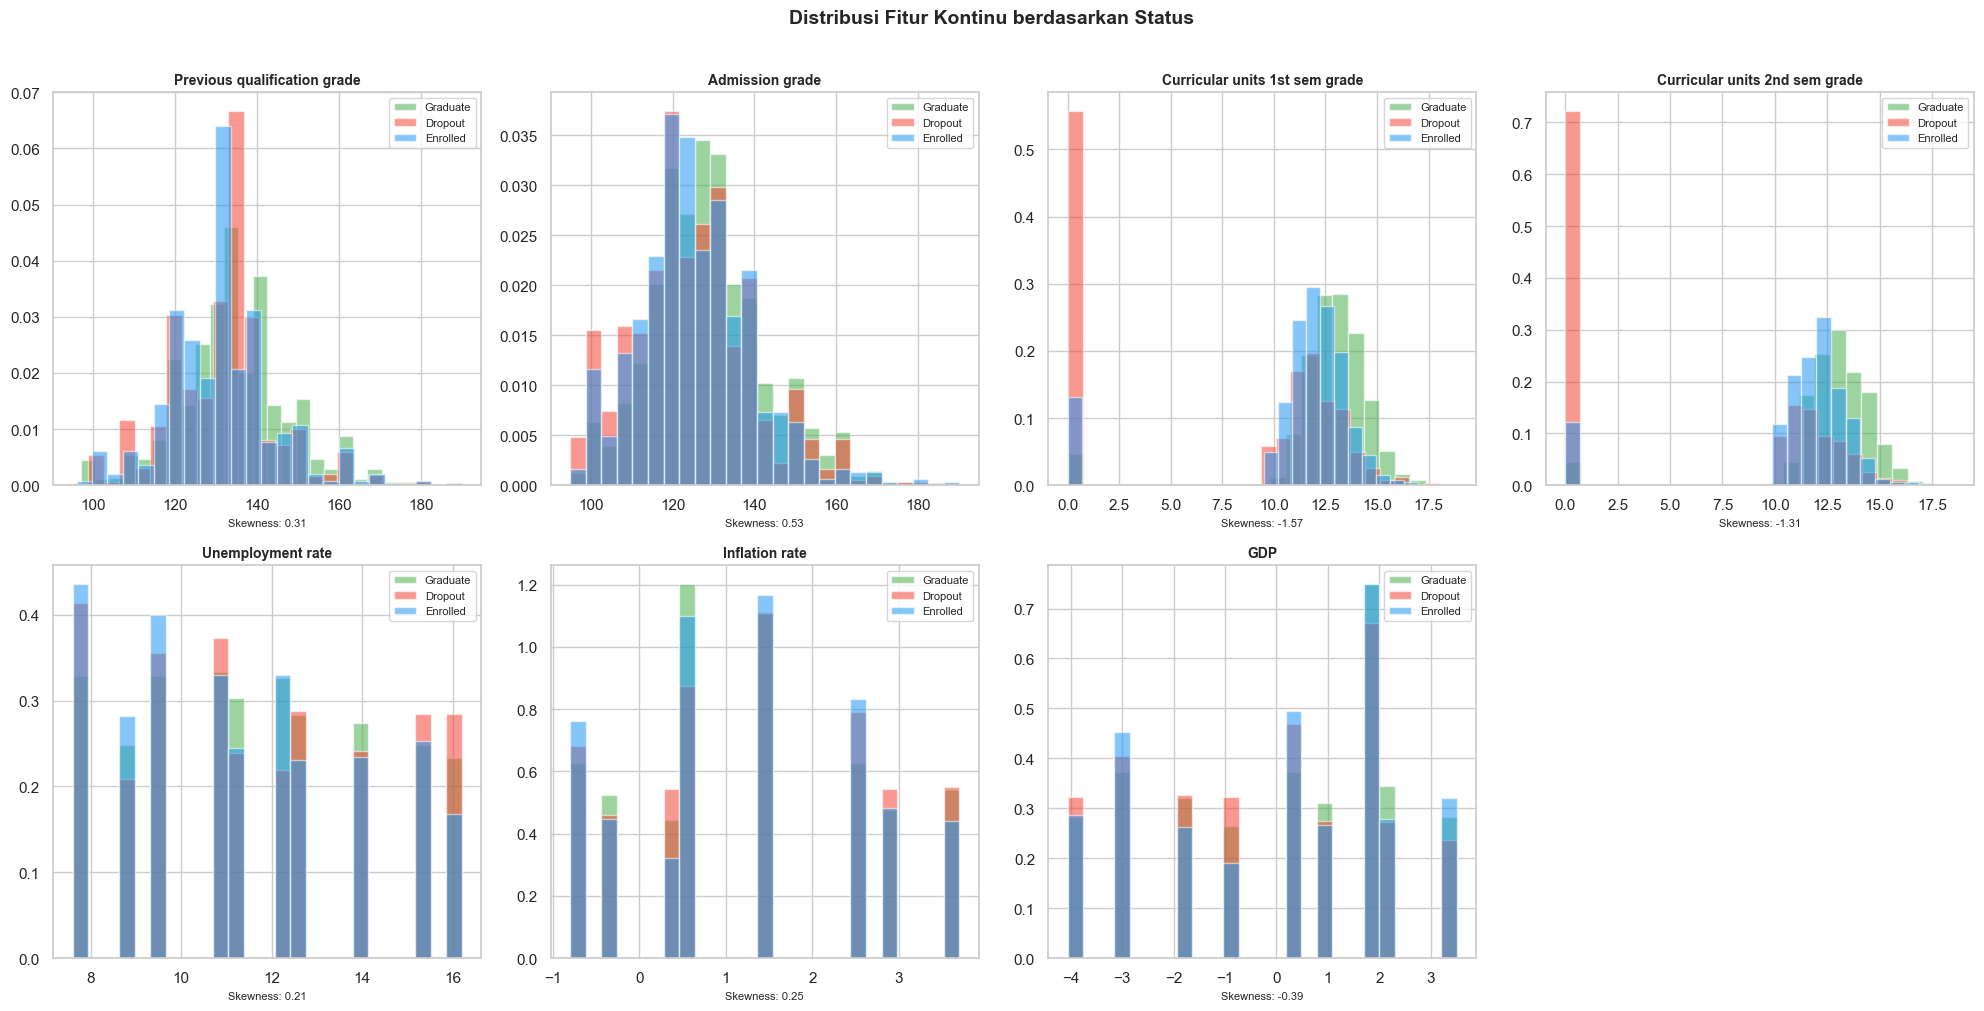

In [8]:
float_cols = df.select_dtypes(include='float64').columns.tolist()
print(f'Kolom kontinu: {float_cols}')

n_cols = 4
n_rows = int(np.ceil(len(float_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten()

palette = {'Graduate': '#4CAF50', 'Dropout': '#F44336', 'Enrolled': '#2196F3'}

for i, col in enumerate(float_cols):
    for status, color in palette.items():
        subset = df[df['Status'] == status][col]
        axes[i].hist(subset, bins=25, alpha=0.55, color=color, label=status, density=True)
    axes[i].set_title(col.replace('_', ' '), fontsize=10, fontweight='bold')
    axes[i].set_xlabel(f'Skewness: {skew(df[col]):.2f}', fontsize=8)
    axes[i].legend(fontsize=8)

for j in range(len(float_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribusi Fitur Kontinu berdasarkan Status', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Performa Akademik vs Status

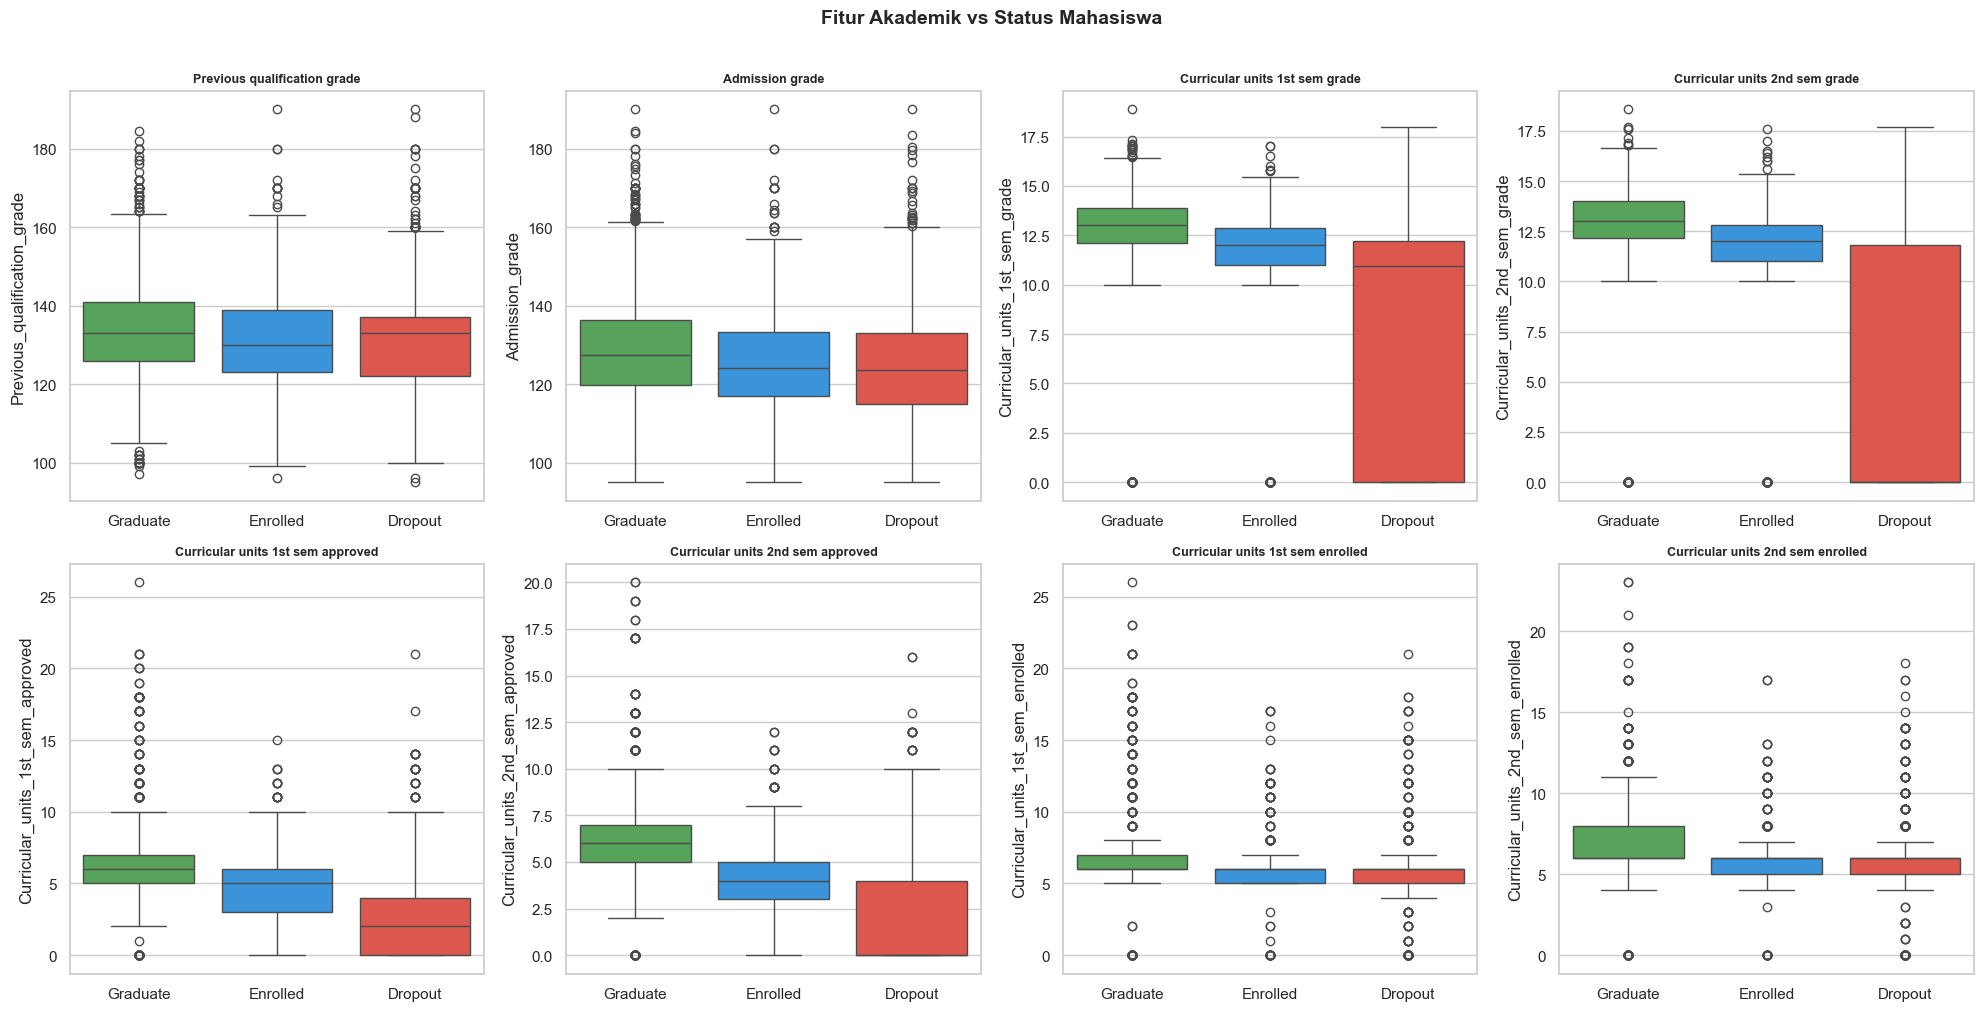

In [9]:
academic_cols = [
    'Previous_qualification_grade', 'Admission_grade',
    'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_grade',
    'Curricular_units_1st_sem_approved', 'Curricular_units_2nd_sem_approved',
    'Curricular_units_1st_sem_enrolled', 'Curricular_units_2nd_sem_enrolled',
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(academic_cols):
    sns.boxplot(x='Status', y=col, data=df,
                order=['Graduate', 'Enrolled', 'Dropout'],
                palette=['#4CAF50', '#2196F3', '#F44336'], ax=axes[i])
    axes[i].set_title(col.replace('_', ' '), fontsize=9, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Fitur Akademik vs Status Mahasiswa', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Fitur Biner vs Status

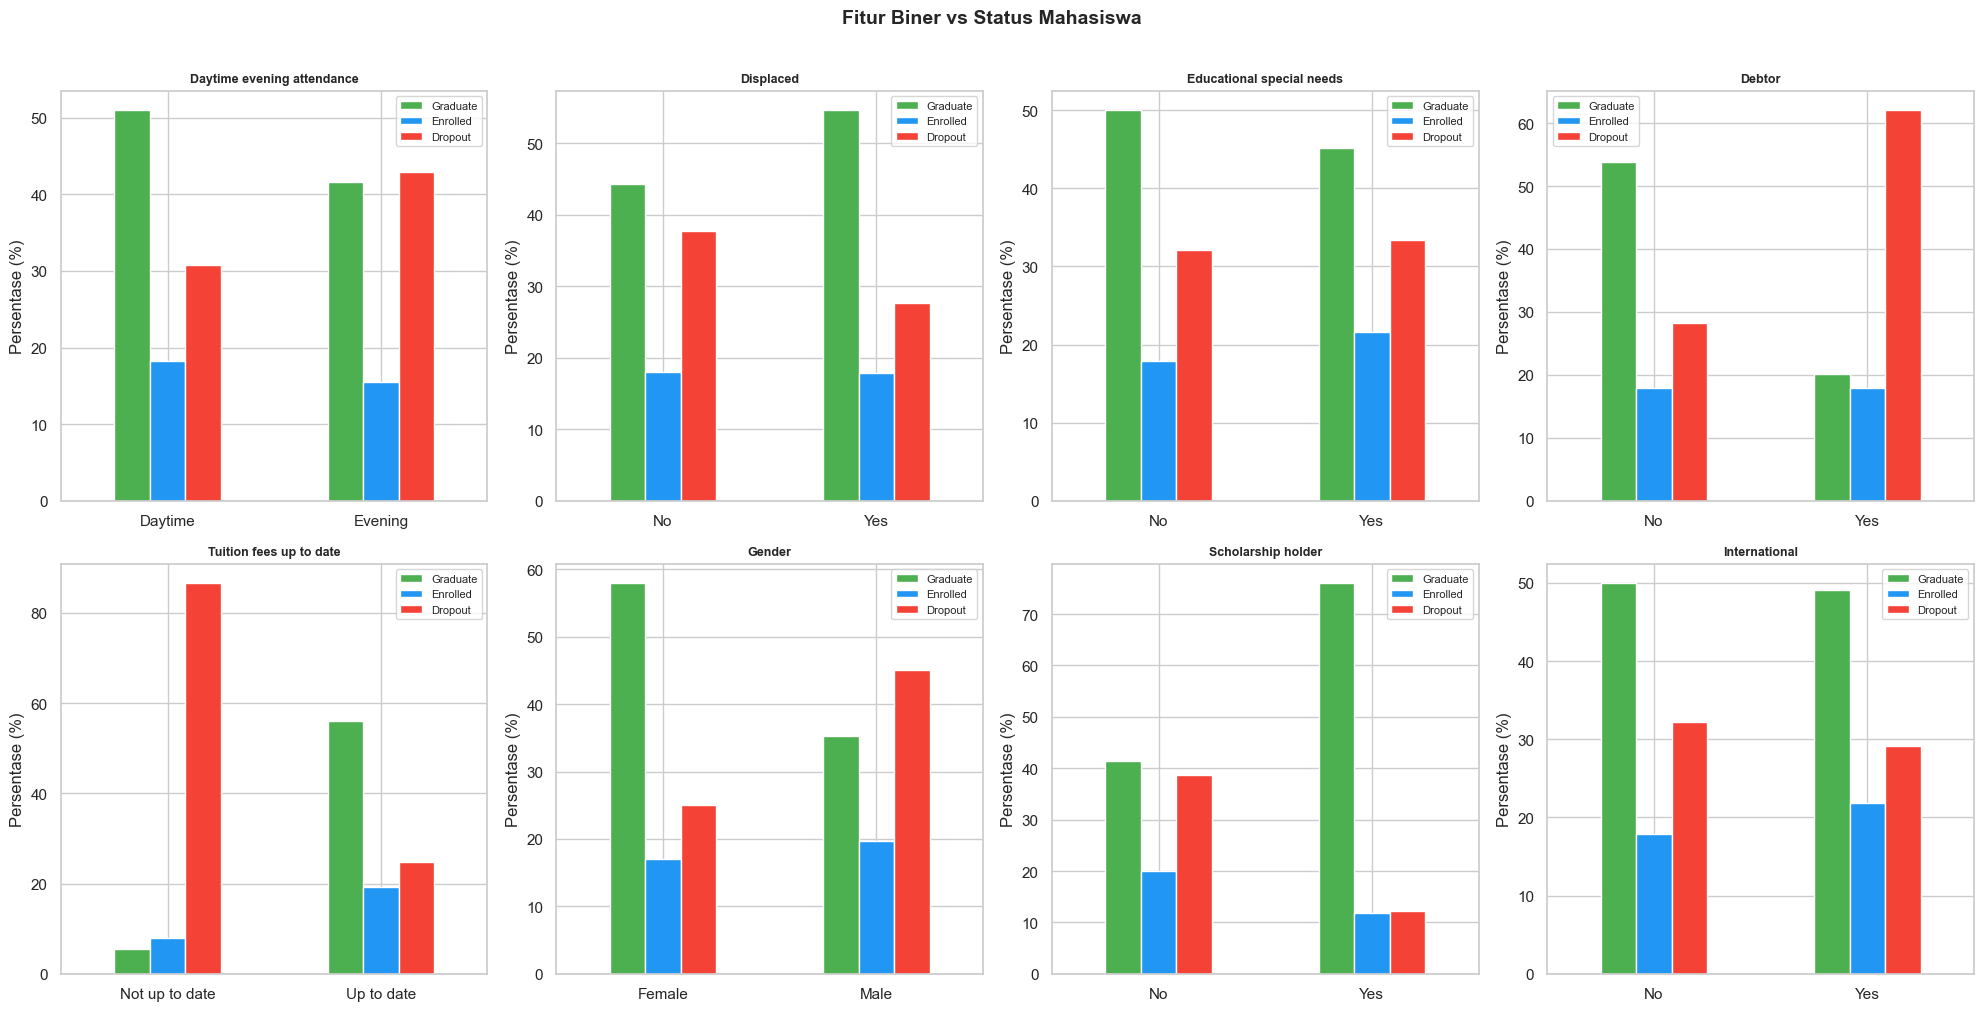

In [10]:
binary_cols = [
    'Daytime_evening_attendance', 'Displaced', 'Educational_special_needs',
    'Debtor', 'Tuition_fees_up_to_date', 'Gender',
    'Scholarship_holder', 'International'
]

label_map = {
    'Daytime_evening_attendance': {1: 'Daytime', 0: 'Evening'},
    'Displaced': {1: 'Yes', 0: 'No'},
    'Educational_special_needs': {1: 'Yes', 0: 'No'},
    'Debtor': {1: 'Yes', 0: 'No'},
    'Tuition_fees_up_to_date': {1: 'Up to date', 0: 'Not up to date'},
    'Gender': {1: 'Male', 0: 'Female'},
    'Scholarship_holder': {1: 'Yes', 0: 'No'},
    'International': {1: 'Yes', 0: 'No'},
}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(binary_cols):
    temp = df.copy()
    temp[col] = temp[col].map(label_map[col])
    ct = pd.crosstab(temp[col], temp['Status'], normalize='index') * 100
    ct = ct.reindex(columns=['Graduate', 'Enrolled', 'Dropout'])
    ct.plot(kind='bar', ax=axes[i],
            color=['#4CAF50', '#2196F3', '#F44336'], edgecolor='white')
    axes[i].set_title(col.replace('_', ' '), fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Persentase (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(fontsize=8)

plt.suptitle('Fitur Biner vs Status Mahasiswa', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Distribusi Usia

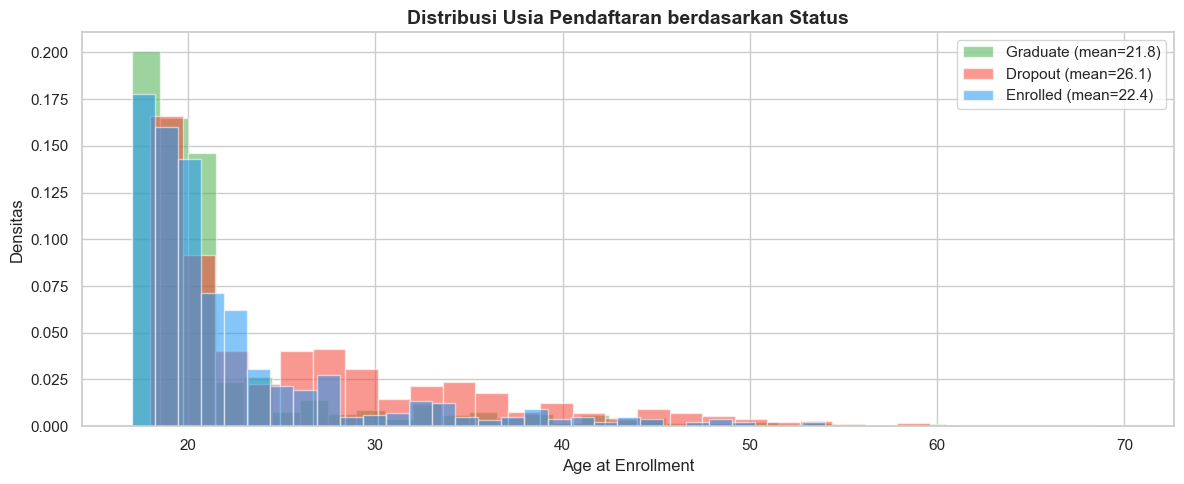

           count   mean   std   min   25%   50%   75%   max
Status                                                     
Dropout   1421.0  26.07  8.70  18.0  19.0  23.0  30.0  70.0
Enrolled   794.0  22.37  6.30  17.0  19.0  20.0  23.0  54.0
Graduate  2209.0  21.78  6.69  17.0  18.0  19.0  21.0  62.0


In [11]:
plt.figure(figsize=(12, 5))
for status, color in [('Graduate','#4CAF50'),('Dropout','#F44336'),('Enrolled','#2196F3')]:
    s = df[df['Status'] == status]['Age_at_enrollment']
    plt.hist(s, bins=30, alpha=0.55, color=color, label=f'{status} (mean={s.mean():.1f})', density=True)

plt.title('Distribusi Usia Pendaftaran berdasarkan Status', fontsize=14, fontweight='bold')
plt.xlabel('Age at Enrollment')
plt.ylabel('Densitas')
plt.legend()
plt.tight_layout()
plt.show()

print(df.groupby('Status')['Age_at_enrollment'].describe().round(2))

### Faktor Ekonomi vs Status

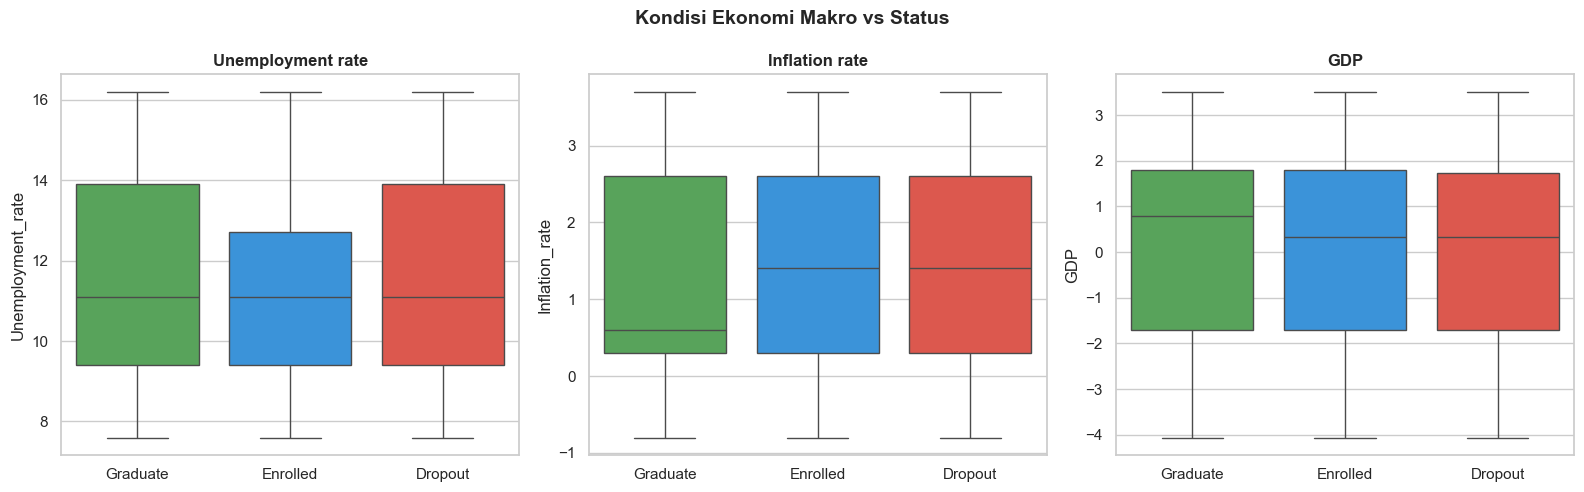

In [12]:
macro_cols = ['Unemployment_rate', 'Inflation_rate', 'GDP']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, macro_cols):
    sns.boxplot(x='Status', y=col, data=df,
                order=['Graduate','Enrolled','Dropout'],
                palette=['#4CAF50','#2196F3','#F44336'], ax=ax)
    ax.set_title(col.replace('_',' '), fontsize=12, fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Kondisi Ekonomi Makro vs Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Outlier Columns

In [13]:
num_all = df.select_dtypes(include=['int64','float64']).columns.tolist()

outlier_info = {}
for col in num_all:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)).sum()
    if n_out > 0:
        outlier_info[col] = n_out

print(f'Kolom dengan outlier ({len(outlier_info)} kolom):')
for k, v in sorted(outlier_info.items(), key=lambda x: -x[1]):
    print(f'  {k:52s}: {v:5d} ({v/len(df)*100:.1f}%)')

Kolom dengan outlier (28 kolom):
  Scholarship_holder                                  :  1099 (24.8%)
  Curricular_units_2nd_sem_grade                      :   877 (19.8%)
  Curricular_units_1st_sem_grade                      :   726 (16.4%)
  Previous_qualification                              :   707 (16.0%)
  Curricular_units_1st_sem_credited                   :   577 (13.0%)
  Application_order                                   :   541 (12.2%)
  Curricular_units_2nd_sem_credited                   :   530 (12.0%)
  Tuition_fees_up_to_date                             :   528 (11.9%)
  Marital_status                                      :   505 (11.4%)
  Debtor                                              :   503 (11.4%)
  Daytime_evening_attendance                          :   483 (10.9%)
  Course                                              :   442 (10.0%)
  Age_at_enrollment                                   :   441 (10.0%)
  Curricular_units_1st_sem_enrolled                   :  

### Correlation Heatmap

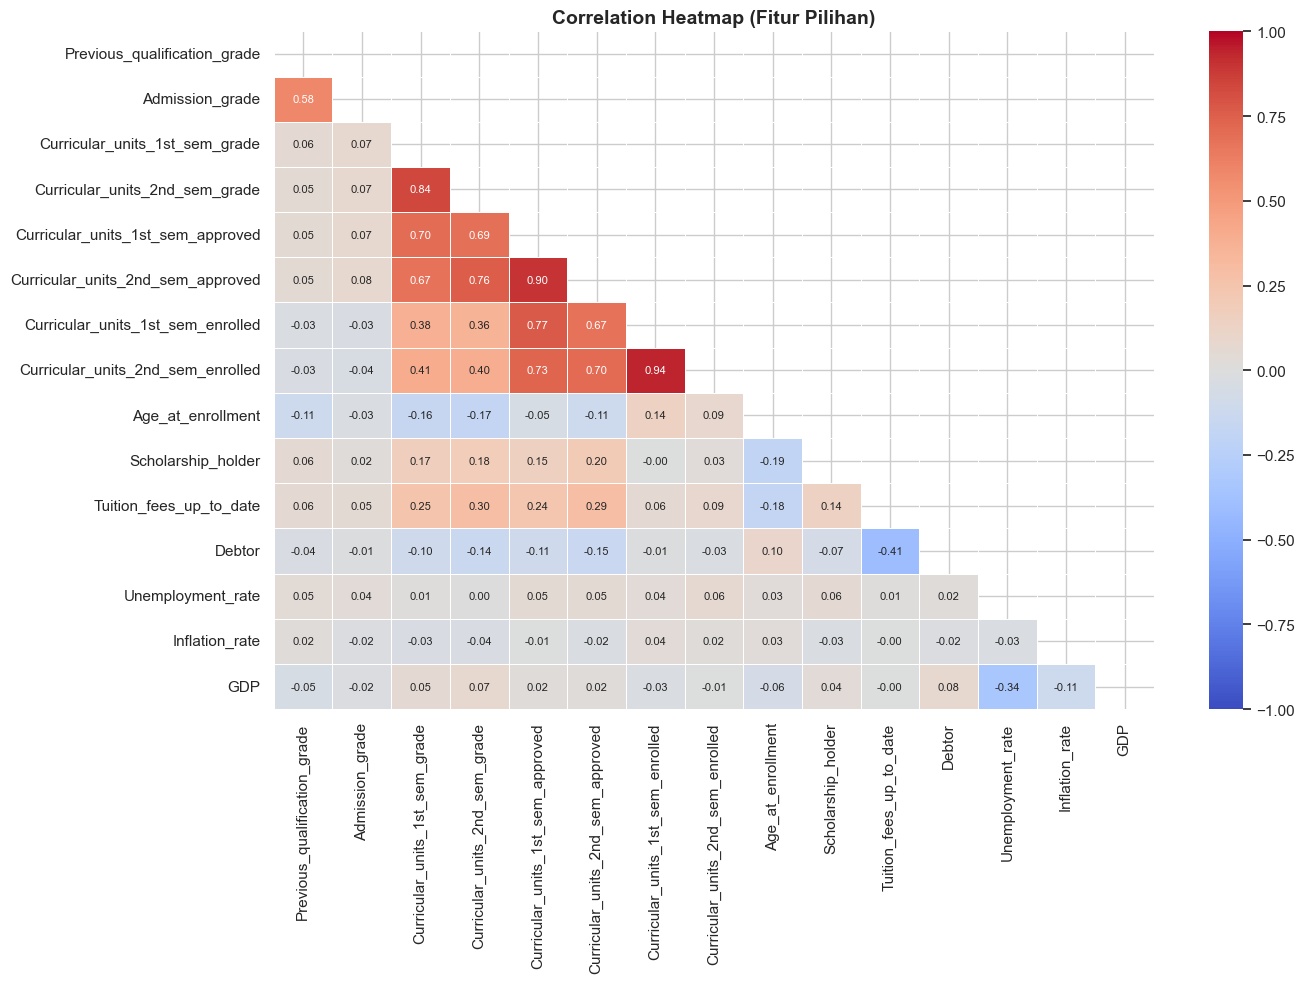

In [14]:
corr_cols = [
    'Previous_qualification_grade', 'Admission_grade',
    'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_grade',
    'Curricular_units_1st_sem_approved', 'Curricular_units_2nd_sem_approved',
    'Curricular_units_1st_sem_enrolled', 'Curricular_units_2nd_sem_enrolled',
    'Age_at_enrollment', 'Scholarship_holder',
    'Tuition_fees_up_to_date', 'Debtor',
    'Unemployment_rate', 'Inflation_rate', 'GDP'
]

plt.figure(figsize=(14, 10))
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.4,
            annot_kws={'size': 8})
plt.title('Correlation Heatmap (Fitur Pilihan)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Data Preprocessing

### Drop Unnesessary Target Label

In [17]:
df = df[df['Status'] != 'Enrolled'].copy()

### Feature Prep and Target Feature Encoding

In [18]:
le_target = LabelEncoder()
y = le_target.fit_transform(df['Status'])

print('Mapping target (Label Encoder):')
for cls, idx in zip(le_target.classes_, le_target.transform(le_target.classes_)):
    print(f'  {cls:10s} -> {idx}')

Mapping target (Label Encoder):
  Dropout    -> 0
  Graduate   -> 1


In [19]:
X = df.drop(columns=['Status'])

print(f'Shape X : {X.shape}')
print(f'Shape y : {y.shape}')
print(f'Tipe kolom X: {X.dtypes.value_counts().to_dict()}')
X.head()

Shape X : (3630, 36)
Shape y : (3630,)
Tipe kolom X: {dtype('int64'): 29, dtype('float64'): 7}


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79


### Train Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]:,} baris ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test : {X_test.shape[0]:,}  baris ({X_test.shape[0]/len(X)*100:.0f}%)')

Train: 2,904 baris (80%)
Test : 726  baris (20%)


### Feature Scaling

In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('StandardScaler diterapkan pada data train & test')

StandardScaler diterapkan pada data train & test


## Modeling

In [22]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = []

for name, model in models.items():
    Xtr = X_train_scaled if name == 'Logistic Regression' else X_train
    Xte = X_test_scaled  if name == 'Logistic Regression' else X_test

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)

    acc = accuracy_score(y_test, y_pred)
    cv  = cross_val_score(model, Xtr, y_train, cv=5, scoring='accuracy').mean()

    results.append({'Model': name, 'Test Accuracy': acc, 'CV Accuracy (5-fold)': cv})
    print(f'{name:25s} | Test Acc: {acc:.4f} | CV Acc: {cv:.4f}')

results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False)
print('\n── Rangkuman ──────────────────────────────────────')
print(results_df.to_string(index=False))

Logistic Regression       | Test Acc: 0.9146 | CV Acc: 0.9081
Decision Tree             | Test Acc: 0.8981 | CV Acc: 0.8888
Random Forest             | Test Acc: 0.9146 | CV Acc: 0.9043
Gradient Boosting         | Test Acc: 0.9118 | CV Acc: 0.9053

── Rangkuman ──────────────────────────────────────
              Model  Test Accuracy  CV Accuracy (5-fold)
Logistic Regression       0.914601              0.908059
      Random Forest       0.914601              0.904271
  Gradient Boosting       0.911846              0.905302
      Decision Tree       0.898072              0.888774


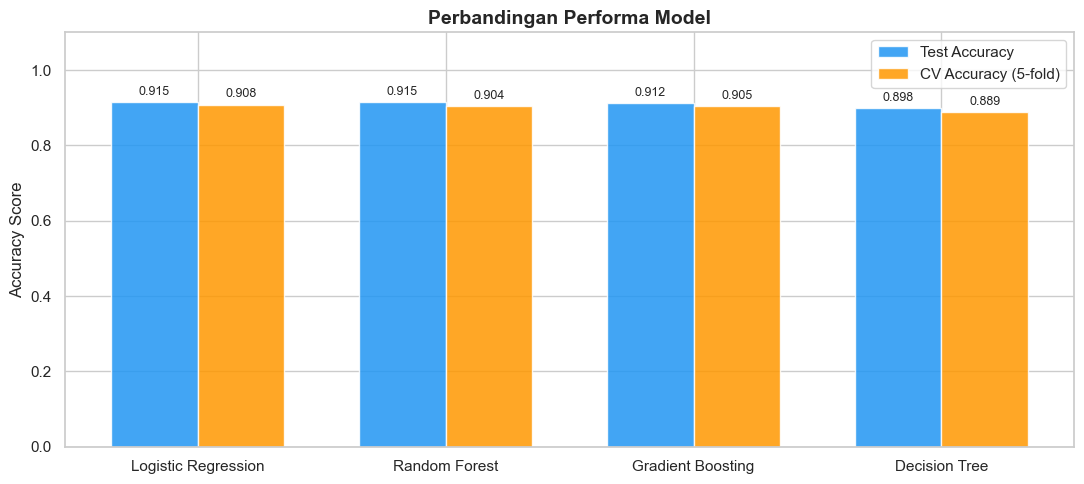

In [23]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(results_df))
width = 0.35

b1 = ax.bar(x - width/2, results_df['Test Accuracy'],        width,
            label='Test Accuracy', color='#2196F3', alpha=0.85)
b2 = ax.bar(x + width/2, results_df['CV Accuracy (5-fold)'], width,
            label='CV Accuracy (5-fold)', color='#FF9800', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy Score', fontsize=12)
ax.set_title('Perbandingan Performa Model', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

for bars in [b1, b2]:
    for bar in bars:
        ax.annotate(f'{bar.get_height():.3f}',
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Best Model  : Logistic Regression
Test Acc    : 0.9146

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.94      0.84      0.88       284
    Graduate       0.90      0.96      0.93       442

    accuracy                           0.91       726
   macro avg       0.92      0.90      0.91       726
weighted avg       0.92      0.91      0.91       726



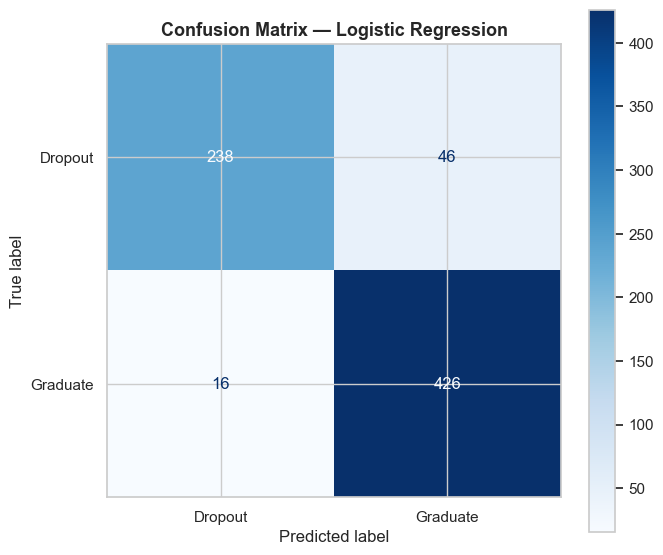

In [24]:
best_name   = results_df.iloc[0]['Model']
best_model  = models[best_name]
Xte_best    = X_test_scaled if best_name == 'Logistic Regression' else X_test
y_pred_best = best_model.predict(Xte_best)

print(f'Best Model  : {best_name}')
print(f'Test Acc    : {results_df.iloc[0]["Test Accuracy"]:.4f}\n')
print('Classification Report:')
print(classification_report(y_test, y_pred_best,
                              target_names=le_target.classes_))

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=le_target.classes_,
    cmap='Blues', ax=ax
)
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
import joblib

# After training
joblib.dump(model, "model/logreg_model.pkl")
joblib.dump(scaler, "model/scaler.pkl")
joblib.dump(le_target, "model/label_encoder.pkl")

['model/label_encoder.pkl']